Import libraries

In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

import collections

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

import pathlib

from sklearn.metrics import classification_report, confusion_matrix




Autotune Data

In [2]:
autotune = tf.data.AUTOTUNE
batch_size = 32
img_size = (150, 150)
class_names = ['normal', 'pneumonia', 'tuberculosis']
buffer_size = 10000

In [3]:
data_root = pathlib.Path( r"/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Applied Data Science/Project 3/archive")

In [4]:
train_dir = data_root/'train'
val_dir = data_root/'val'
test_dir = data_root/'test'

In [9]:
train_ds =tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size = img_size,
    color_mode = 'grayscale',
    batch_size = batch_size,
    shuffle = True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size = img_size,
    color_mode = 'grayscale',
    batch_size = batch_size,
    shuffle =False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size = img_size,
    color_mode = 'grayscale',
    batch_size = batch_size,
    shuffle = False
)

print('Inferred Class Names:', train_ds.class_names)
num_classes = len(train_ds.class_names)

Found 20450 files belonging to 3 classes.
Found 2534 files belonging to 3 classes.
Found 2569 files belonging to 3 classes.
Inferred Class Names: ['normal', 'pneumonia', 'tuberculosis']


In [ ]:
train_ds = train_ds.cache().shuffle(buffer_size).prefetch(buffer_size = autotune)
val_ds = val_ds.cache().prefetch(buffer_size = autotune)
test_ds = test_ds.cache().prefetch(buffer_size = autotune)


Calculate class weights to handle class imbalance

In [ ]:


class_counts = collections.Counter()

for _, labels in train_ds:
    class_counts.update(labels.numpy().tolist())
print('Class Counts:', class_counts)

normal_iamage_count = class_counts[0]
pneumonia_image_count = class_counts[1]
tuberculosis_image_count = class_counts[2]
total_image_count = sum(class_counts.values())

weight_for_normal = total_image_count / (3 * normal_iamage_count)
weight_for_pneumonia = total_image_count / (3 * pneumonia_image_count)
weight_for_tuberculosis = total_image_count / (3 * tuberculosis_image_count)
class_weight = {
    0: weight_for_normal, 
    1: weight_for_pneumonia, 
    2: weight_for_tuberculosis}

print('Class Weights:' , class_weight)

    

Class Counts: Counter({2: 8513, 0: 7263, 1: 4674})
Class Weights: {0: 0.9385469732433797, 1: 1.4584224789616318, 2: 0.8007361290575199}


2025-11-15 21:03:52.410475: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Visualize Data

2025-11-15 21:06:02.256658: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


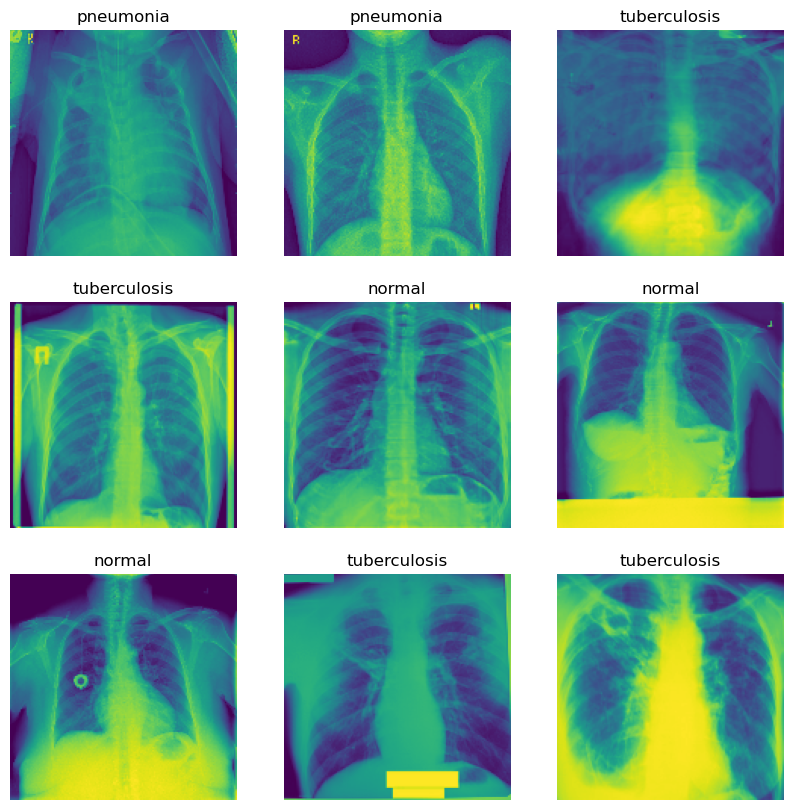

In [16]:
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(np.squeeze(images[i].numpy().astype('uint8')))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis('off')

Build CNN

In [18]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

inputs = tf.keras.Input(shape = img_size + (1,))
x = data_augmentation(inputs)
x = tf.keras.layers.Rescaling(1./255)(x)

x = tf.keras.layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same')(x)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same')(x)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same')(x)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(128, activation = 'relu')(x)

outputs = tf.keras.layers.Dense(num_classes, activation = 'softmax')(x)

model = tf.keras.Model(inputs = inputs, outputs = outputs)


In [19]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,571 (428.01 KB)

 Trainable params: 109,571 (428.01 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [20]:
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 20,
    class_weight = class_weight
)

Epoch 1/20


2025-11-15 21:27:18.602916: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


640/640 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.5381 - loss: 0.8766 - val_accuracy: 0.5722 - val_loss: 0.8472
Epoch 2/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.5553 - loss: 1.0011 - val_accuracy: 0.5616 - val_loss: 1.8391
Epoch 3/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.4988 - loss: 3.9613 - val_accuracy: 0.4219 - val_loss: 22.0870
Epoch 4/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.4871 - loss: 19.7246 - val_accuracy: 0.5545 - val_loss: 8.2096
Epoch 5/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.4964 - loss: 33.3673 - val_accuracy: 0.5328 - val_loss: 55.4714
Epoch 6/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.4809 - loss: 63.5835 - val_accuracy: 0.4657 - val_loss: 103.9677
Epoch 7/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.4905 - loss: 93.9355 - val_accuracy: 0.3788 - val_loss: 143.9729
Epoch 8/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.4865 - loss: 133.6763 -

Evaluate

In [21]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy:.4f}")

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4371 - loss: 1399.1624
Test Accuracy: 0.4371
